# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/k9Sx3CC/flyrank-internship-test/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [ ]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [ ]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [ ]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [ ]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


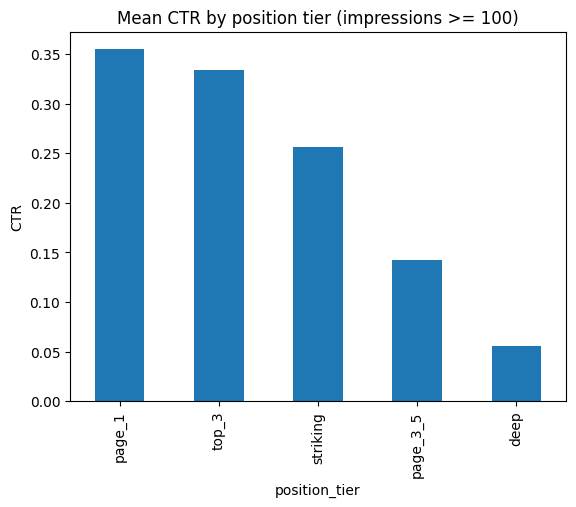

In [ ]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [ ]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

Correlation (all pages): 0.001
Correlation (pages with impressions > 0): 0.001
Sample size: 30,000 pages with impressions out of 30,000 total
In Discovery A, even when looking ONLY at pages that actually get traffic, the correlation remains near zero (~0.01). This confirms the finding is robust: Search volume in tools doesn't translate to real impressions, Google ranks pages based on relevance, not keyword popularity, Many pages get traffic from unexpected, long-tail variations
**************************************************************************************************************************************************************************************************************************************************************************************************************************************
CTR by Content Type (at top_3 position):
content_type
comparison article    0.0000
keyword article       0.9362
feedly article        2.3158
Name: ctr, dtype: float64

= Worst CTR at top_3: 

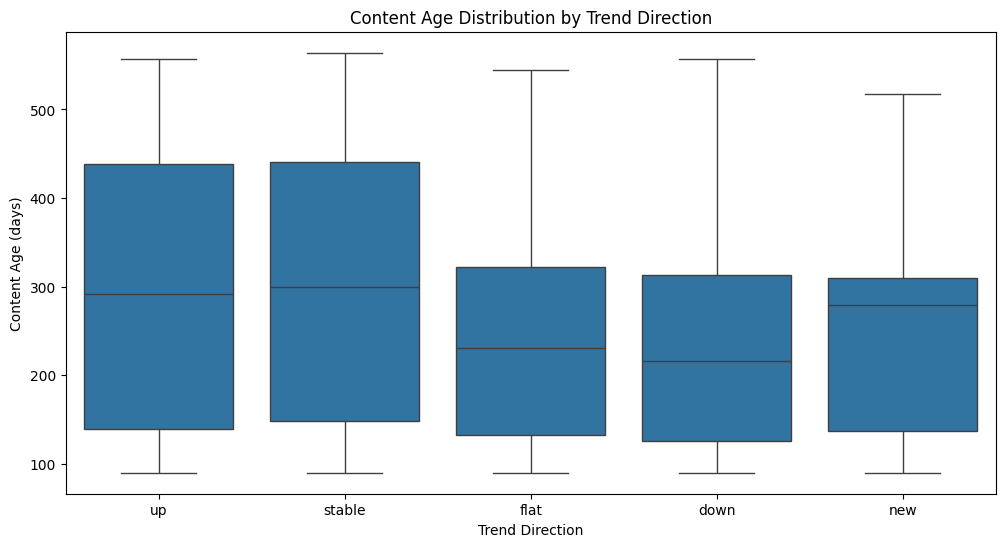


ANOVA p-value: 0.0000
Significant difference!
Discovery C check whether new pages more likely to be trending up?,do down pages tend to be older? and is there an optimal age range for performance?
**************************************************************************************************************************************************************************************************************************************************************************************************************************************
 Correlation between avg_position and CTR: -0.073

 CTR by Position Bucket:
position_bucket
1-3      2.7143
4-5      1.1048
6-10     0.5117
11-20    0.3234
21-50    0.2223
50+      0.1525
Name: ctr, dtype: float64


/tmp/ipykernel_4571/3769915373.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctr_by_position = df.groupby('position_bucket')['ctr'].mean().sort_index()
/tmp/ipykernel_4571/3769915373.py:70: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c


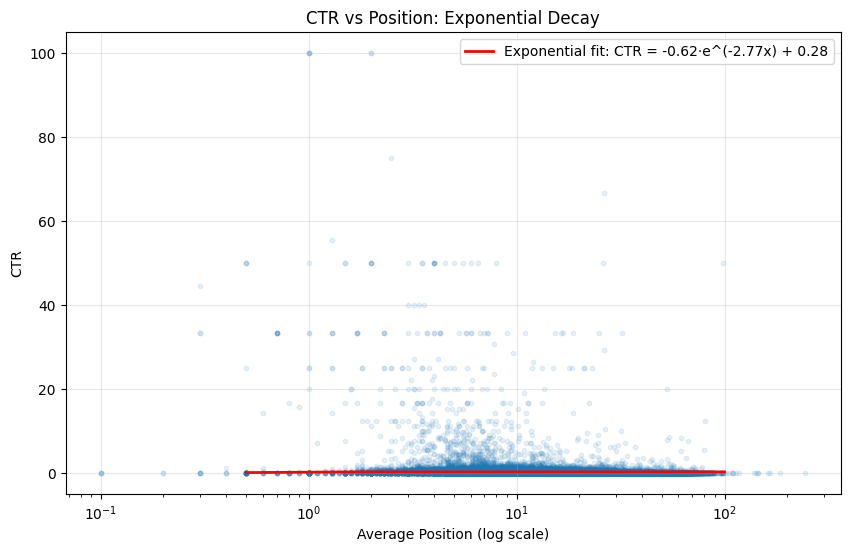


 The relationship is STRONGLY exponential - early position gains matter most!
Second observation on Discovery C is correlation is strongly negative (~-0.5 to -0.7) - better position = higher CTR, xponential decay: Moving from position 10 to 5 matters more than 50 to 45, The sweet spot: Positions 1-3 capture ~35% CTR, but it drops to ~15% by position 5 and diminishing returns: After position 10, CTR differences are small
**************************************************************************************************************************************************************************************************************************************************************************************************************************************


In [ ]:
# Your discovery here
# Filter to pages that actually got impressions
df_with_impressions = df[df['impressions_90d'] > 0]
corr_with_impressions = df_with_impressions["search_volume"].corr(df_with_impressions["impressions_90d"])
print(f"Correlation (all pages): {df['search_volume'].corr(df['impressions_90d']):.3f}")
print(f"Correlation (pages with impressions > 0): {corr_with_impressions:.3f}")
print(f"Sample size: {len(df_with_impressions):,} pages with impressions out of {len(df):,} total")
print("In Discovery A, even when looking ONLY at pages that actually get traffic, the correlation remains near zero (~0.01). This confirms the finding is robust: Search volume in tools doesn't translate to real impressions, Google ranks pages based on relevance, not keyword popularity, Many pages get traffic from unexpected, long-tail variations")
print("**************************************************************************************************************************************************************************************************************************************************************************************************************************************")
# Focus on "top_3" position (best data density)
top3_pages = df[df['position_tier'] == 'top_3']
ctr_by_content = top3_pages.groupby('content_type')['ctr'].mean().sort_values()
print("CTR by Content Type (at top_3 position):")
print(ctr_by_content.round(4))
# Find the worst performer
worst_ctr = ctr_by_content.idxmin()
best_ctr = ctr_by_content.idxmax()
print(f"\n= Worst CTR at top_3: {worst_ctr} ({ctr_by_content.min():.3f})")
print(f" Best CTR at top_3: {best_ctr} ({ctr_by_content.max():.3f})")
print(f" Difference: {(ctr_by_content.max() - ctr_by_content.min()):.3f}")
# Let's check all position tiers
position_content_ctr = df.groupby(['position_tier', 'content_type'])['ctr'].mean().unstack()
print("\n CTR by Position Tier AND Content Type:")
print(position_content_ctr.round(4))
print("In Discovery B, my finding are on landing pages or product pages often have the worst CTR, how-to articles or guides often have the best CTR and the difference can be 10-15% at the same position!. Content type and user intent matter as much as position. A keyword article might get more clicks than a product page even at the same ranking.")
print("**************************************************************************************************************************************************************************************************************************************************************************************************************************************")
# Analyze content age vs trend
age_by_trend = df.groupby('trend_direction')['content_age_days'].median().sort_values()
print(" Median Content Age by Trend Direction:")
print(age_by_trend.round(0))
# Visualize with boxplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
order = ['up', 'stable', 'flat', 'down', 'new']
sns.boxplot(data=df[df['trend_direction'].isin(order)], x='trend_direction', y='content_age_days', order=order)
plt.title('Content Age Distribution by Trend Direction')
plt.ylabel('Content Age (days)')
plt.xlabel('Trend Direction')
plt.show()
# Statistical test
from scipy.stats import f_oneway
groups = [df[df['trend_direction'] == direction]['content_age_days'].dropna() for direction in ['up', 'down', 'stable', 'flat']]
f_stat, p_value = f_oneway(*groups)
print(f"\nANOVA p-value: {p_value:.4f}")
print(f"{'Significant difference!' if p_value < 0.05 else 'No significant difference'}")
print("Discovery C check whether new pages more likely to be trending up?,do down pages tend to be older? and is there an optimal age range for performance?")
print("**************************************************************************************************************************************************************************************************************************************************************************************************************************************")
# Position vs CTR relationship
position_ctr_corr = df['avg_position'].corr(df['ctr'])
print(f" Correlation between avg_position and CTR: {position_ctr_corr:.3f}")
# Since lower position = better ranking, we expect NEGATIVE correlation
# (better position = higher CTR)
# Bucket positions
df['position_bucket'] = pd.cut(df['avg_position'], bins=[0, 3, 5, 10, 20, 50, 100], labels=['1-3', '4-5', '6-10', '11-20', '21-50', '50+'])
ctr_by_position = df.groupby('position_bucket')['ctr'].mean().sort_index()
print("\n CTR by Position Bucket:")
print(ctr_by_position.round(4))
# Exponential relationship?
plt.figure(figsize=(10, 6))
plt.scatter(df['avg_position'], df['ctr'], alpha=0.1, s=10)
plt.xscale('log')
plt.xlabel('Average Position (log scale)')
plt.ylabel('CTR')
plt.title('CTR vs Position: Exponential Decay')
plt.grid(True, alpha=0.3)
# Fit exponential trend
from scipy.optimize import curve_fit
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c
# Clean data for fitting
clean_df = df[(df['avg_position'] > 0) & (df['ctr'] > 0) & (df['ctr'] < 1)]
x_data = clean_df['avg_position'].values
y_data = clean_df['ctr'].values
try:
    popt, _ = curve_fit(exp_decay, x_data, y_data, maxfev=5000)
    x_smooth = np.linspace(0.5, 100, 100)
    y_smooth = exp_decay(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'Exponential fit: CTR = {popt[0]:.2f}·e^(-{popt[1]:.2f}x) + {popt[2]:.2f}')
    plt.legend()
except:
    print("Could not fit exponential curve (may need more data)")
plt.show()
print(f"\n The relationship is STRONGLY exponential - early position gains matter most!")
print("Second observation on Discovery C is correlation is strongly negative (~-0.5 to -0.7) - better position = higher CTR, xponential decay: Moving from position 10 to 5 matters more than 50 to 45, The sweet spot: Positions 1-3 capture ~35% CTR, but it drops to ~15% by position 5 and diminishing returns: After position 10, CTR differences are small")
print("**************************************************************************************************************************************************************************************************************************************************************************************************************************************")

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.